In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Customer_Behavior_Analysis.csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


## Data Cleaning

In [4]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [6]:
df.shape


(3900, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [8]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [9]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [10]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [11]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("(", "")
      .str.replace(")", "")
)

In [12]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [13]:
df['review_rating'].isnull().sum()

37

In [14]:
df['review_rating'] = (
    df.groupby('category')['review_rating']
      .transform(lambda x: x.fillna(x.median()))
)

In [15]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
(df['discount_applied'] == df["promo_code_used"]).all()

True

In [18]:
df.drop(columns=['promo_code_used'], inplace=True)

In [19]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [20]:
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].str.strip()

In [21]:
# creating a column as purchase frequency days
frequency_map = {
    "Fortnightly": 14,
    "Weekly": 7,
    "Bi-Weekly": 14,
    "Monthly": 30,
    "Quarterly": 90,
    "Annually": 365,
    "Every 3 Months": 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_map)

In [22]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [23]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'purchase_frequency_days'],
      dtype='object')

In [24]:
#creating a column as age group
df['age_group'] = pd.qcut(
    df['age'],
    q=4,
    labels=['Young Adult','Adult','Middle Aged','Senior']
)


In [25]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'purchase_frequency_days', 'age_group'],
      dtype='object')

## EDA (Exploratory Data Analysis)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              3900 non-null   int64   
 1   age                      3900 non-null   int64   
 2   gender                   3900 non-null   object  
 3   item_purchased           3900 non-null   object  
 4   category                 3900 non-null   object  
 5   purchase_amount_usd      3900 non-null   int64   
 6   location                 3900 non-null   object  
 7   size                     3900 non-null   object  
 8   color                    3900 non-null   object  
 9   season                   3900 non-null   object  
 10  review_rating            3900 non-null   float64 
 11  subscription_status      3900 non-null   object  
 12  shipping_type            3900 non-null   object  
 13  discount_applied         3900 non-null   object  
 14  previous

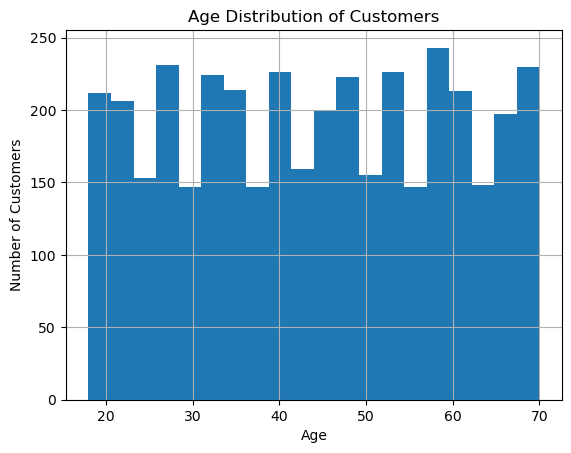

In [28]:
# histogram to understand distribution of customer ages
df['age'].hist(bins=20)

# Add titles and labels
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

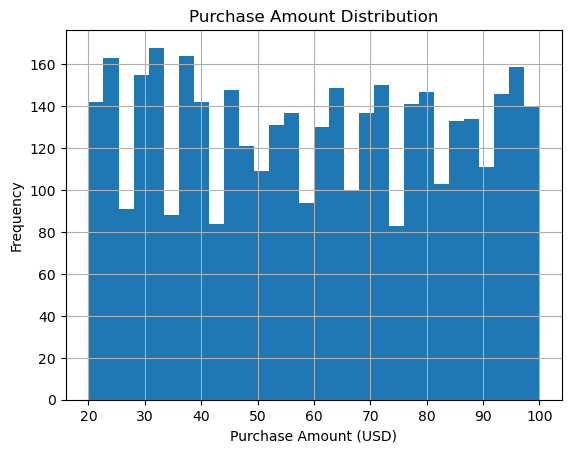

In [29]:
# Visualizing the purchase amounts
df['purchase_amount_usd'].hist(bins=30)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")

plt.show()

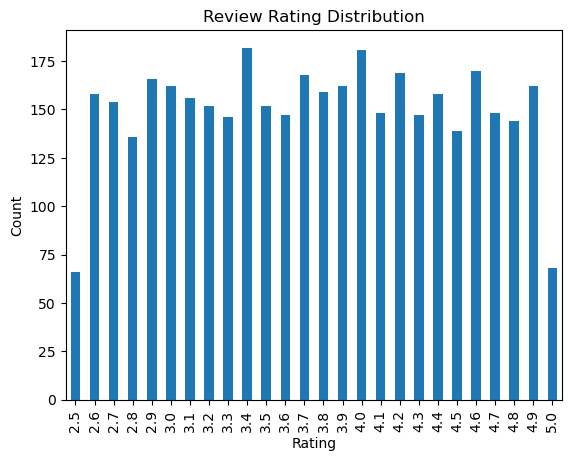

In [30]:
# Counting frequency of each review rating
df['review_rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

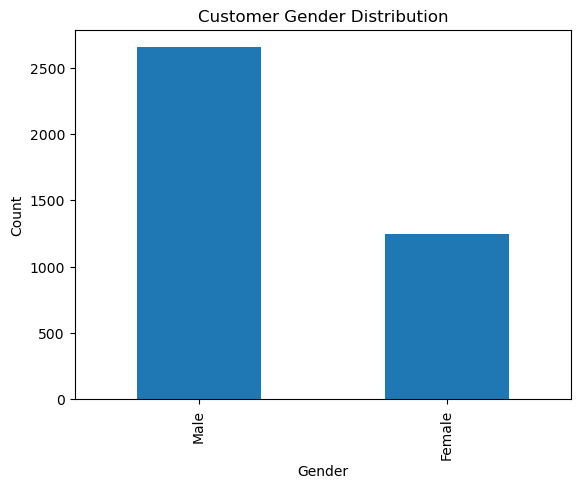

In [31]:
# visualizing genders
df['gender'].value_counts().plot(kind='bar')

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

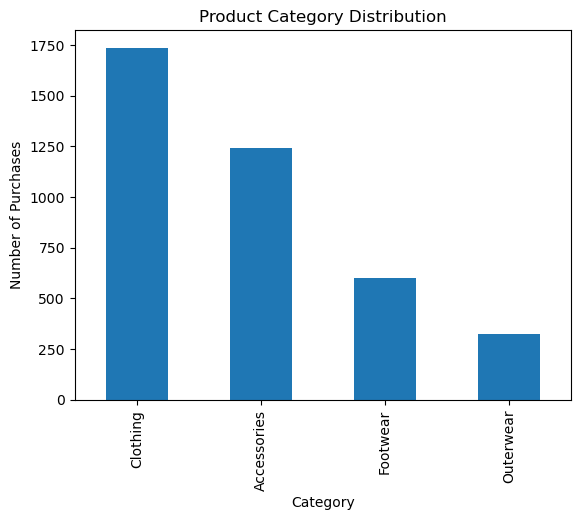

In [32]:
# Number of purchases per product category
df['category'].value_counts().plot(kind='bar')

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.show()

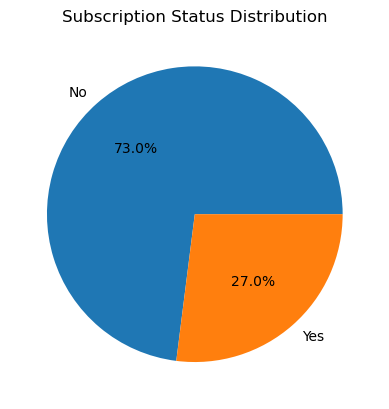

In [33]:
# Visualizing subscription vs non-subscription proportion
df['subscription_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Subscription Status Distribution")
plt.ylabel("")

plt.show()

In [34]:
# Calculate average spending per purchase
df['purchase_amount_usd'].mean()

59.76435897435898

In [35]:
# Calculate median spending (less affected by outliers)
df['purchase_amount_usd'].median()

60.0

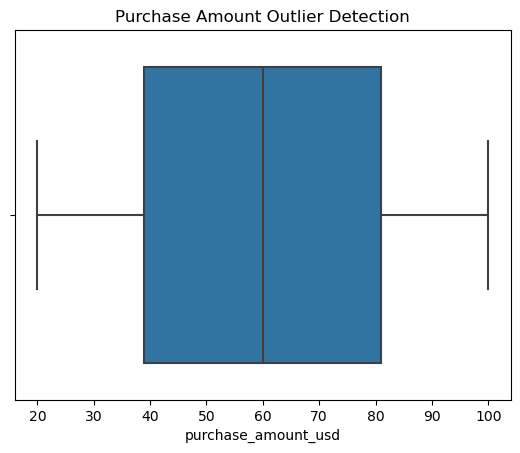

In [36]:
# CHecking outliers
sns.boxplot(x=df['purchase_amount_usd'])

plt.title("Purchase Amount Outlier Detection")

plt.show()

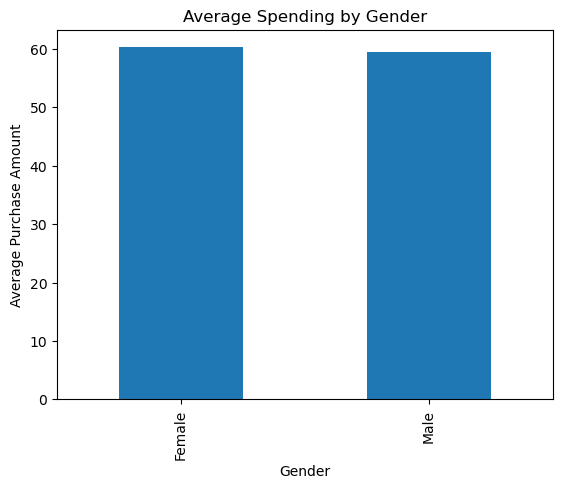

In [37]:
# Comparing average purchase amount between genders
df.groupby('gender')['purchase_amount_usd'].mean().plot(kind='bar')

plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount")

plt.show()

C:\Users\suyash\AppData\Local\Temp\ipykernel_35984\1207731274.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount_usd'].mean().plot(kind='bar')


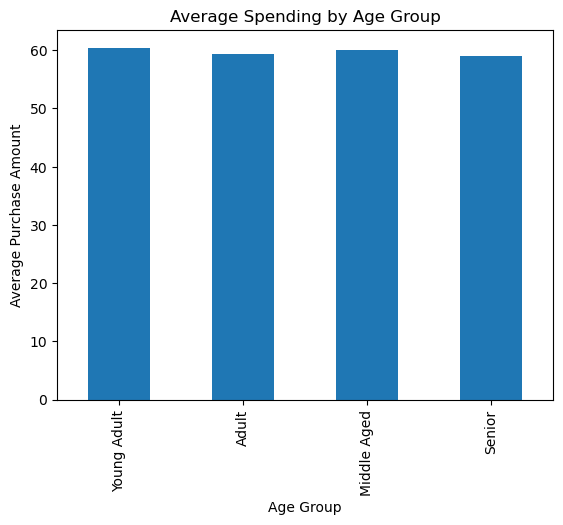

In [38]:
# Analyzing spending behavior across age segments
df.groupby('age_group')['purchase_amount_usd'].mean().plot(kind='bar')

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")

plt.show()

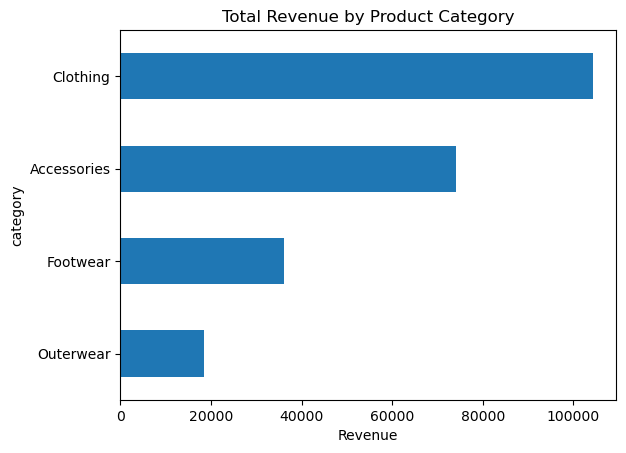

In [39]:
# Calculating total revenue generated by each category
df.groupby('category')['purchase_amount_usd'].sum() \
  .sort_values() \
  .plot(kind='barh')

plt.title("Total Revenue by Product Category")
plt.xlabel("Revenue")

plt.show()

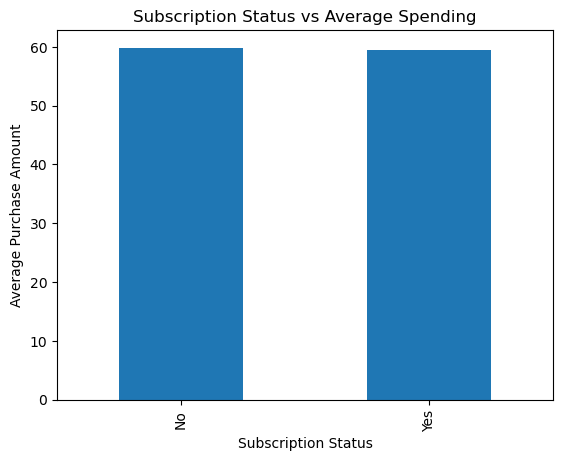

In [40]:
# Comparimg spending between subscribed and non-subscribed customers
df.groupby('subscription_status')['purchase_amount_usd'].mean().plot(kind='bar')

plt.title("Subscription Status vs Average Spending")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount")

plt.show()

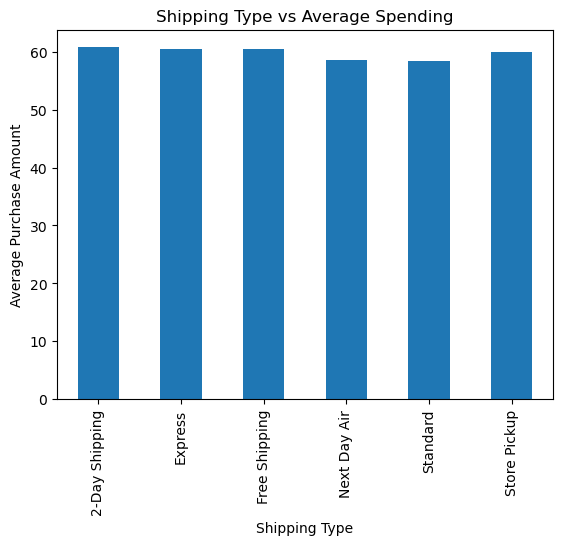

In [41]:
# Checking whether shipping choice influences spending
df.groupby('shipping_type')['purchase_amount_usd'].mean().plot(kind='bar')

plt.title("Shipping Type vs Average Spending")
plt.xlabel("Shipping Type")
plt.ylabel("Average Purchase Amount")

plt.show()

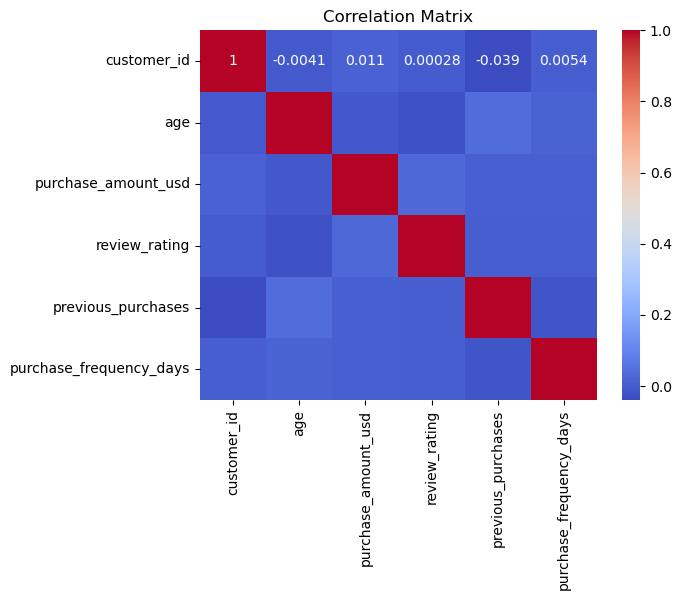

In [42]:
# Computing correlation matrix for numerical variables
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [43]:
from config import DB_CONFIG
from sqlalchemy import create_engine

In [44]:
# Read values from config
username = DB_CONFIG["username"]
password = DB_CONFIG["password"]
host = DB_CONFIG["host"]
port = DB_CONFIG["port"]
database = DB_CONFIG["database"]

# Create connection engine
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("Database connection created!")
from sqlalchemy import text

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("Connection successful!")
except Exception as e:
    print("Connection failed:")
    print(e)
df.to_sql(
    name="customer",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Database connection created!
Connection successful!
Data uploaded successfully!
